# Tomography Analysis: Paranal Cn2 Profile

This notebook demonstrates the new "first-class" tomography support in `otbench`, including:
1.  **Vector Target Loading**: Loading the full `cn2_profile` task.
2.  **Granular Evaluation**: Using `detailed=True` to get per-altitude metrics.
3.  **Physics Check**: Calculating the `IntegratedSeeingMetric`.
4.  **Visualization**: Using `otbench.plot` to visualize profile structure and evolution.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import otbench.eval as eval_metrics
from otbench.tasks import TaskApi
from otbench.benchmark.models.regression import PersistenceRegressionModel
from otbench.plot.tomography import plot_profile_comparison, plot_time_series_heatmap

## 1. Load Task and Data

In [2]:
task_api = TaskApi()
task_name = "regression.paranal_tomography_v2.full.cn2_profile"
task = task_api.get_task(task_name)

print(f"Task: {task.get_description()}")
print(f"Target: {task.get_target_name()}")

X_train, y_train = task.get_train_data()
X_test, y_test = task.get_test_data()

Task: Regression task for Paranal Cn2 Profile Reconstruction
Target: ['cn2_free_atmos_cn2_free_atmos_500', 'cn2_free_atmos_cn2_free_atmos_1000', 'cn2_free_atmos_cn2_free_atmos_2000', 'cn2_free_atmos_cn2_free_atmos_4000', 'cn2_free_atmos_cn2_free_atmos_8000', 'cn2_free_atmos_cn2_free_atmos_16000', 'cn2_boundary_cn2_boundary_1', 'cn2_boundary_cn2_boundary_2', 'cn2_boundary_cn2_boundary_3', 'cn2_boundary_cn2_boundary_4', 'cn2_boundary_cn2_boundary_5', 'cn2_boundary_cn2_boundary_6', 'cn2_boundary_cn2_boundary_7', 'cn2_boundary_cn2_boundary_8', 'cn2_ground_scalar']


## 2. Train Baseline Model (Persistence)

In [3]:
model = PersistenceRegressionModel(name="Persistence", target_name="cn2_profile")
model.train(X_train, y_train)

# Determine output size context (if needed by nicer models)
output_size = y_train.shape[1]
print(f"Vector Target Size: {output_size}")

Vector Target Size: 15


## 3. Granular Evaluation

In [4]:
# Evaluate with detailed_metrics=True
metrics, y_pred = task.evaluate_model(model.predict, return_predictions=True, detailed_metrics=True)

print("Overall Metrics:")
for k, v in metrics.items():
    if k in ["detailed_score", "seeing_true", "seeing_pred"]:
        continue
    if isinstance(v, dict):
        print(f"{k}: {v['metric_value']:.4e}")

# Inspect detailed scores (e.g. RMSE per layer)
rmse_detailed = metrics['root_mean_square_error']['detailed_score']
layers = task.get_target_name()
print("\nPer-Layer RMSE:")
for layer, score in zip(layers, rmse_detailed):
    print(f"{layer}: {score:.4e}")

Overall Metrics:
root_mean_square_error: 1.8725e+00
mean_absolute_error: 1.2808e+00

Per-Layer RMSE:
cn2_free_atmos_cn2_free_atmos_500: 8.6494e-01
cn2_free_atmos_cn2_free_atmos_1000: 9.9716e-01
cn2_free_atmos_cn2_free_atmos_2000: 1.2270e+00
cn2_free_atmos_cn2_free_atmos_4000: 6.9002e-01
cn2_free_atmos_cn2_free_atmos_8000: 1.0804e+00
cn2_free_atmos_cn2_free_atmos_16000: 4.6521e-01
cn2_boundary_cn2_boundary_1: 8.4237e-01
cn2_boundary_cn2_boundary_2: 1.1320e+00
cn2_boundary_cn2_boundary_3: 3.6933e+00
cn2_boundary_cn2_boundary_4: 3.4420e+00
cn2_boundary_cn2_boundary_5: 3.4943e+00
cn2_boundary_cn2_boundary_6: 3.3874e+00
cn2_boundary_cn2_boundary_7: 3.1263e+00
cn2_boundary_cn2_boundary_8: 3.3774e+00
cn2_ground_scalar: 2.6752e-01


/home/cjellen/projects/github/otbench/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 4. Physics Check: Integrated Seeing

In [5]:
# Calculate integrated seeing metric
# Note: need to parse heights properly or assume uniform for this demo
res_seeing = eval_metrics.integrated_seeing(y_test, y_pred, detailed=True)
print(f"Integrated Seeing RMSE (arcsec error): {res_seeing['metric_value']:.4f}")

Integrated Seeing RMSE (arcsec error): 0.0000


## 5. Visualization

<Figure size 1000x800 with 0 Axes>

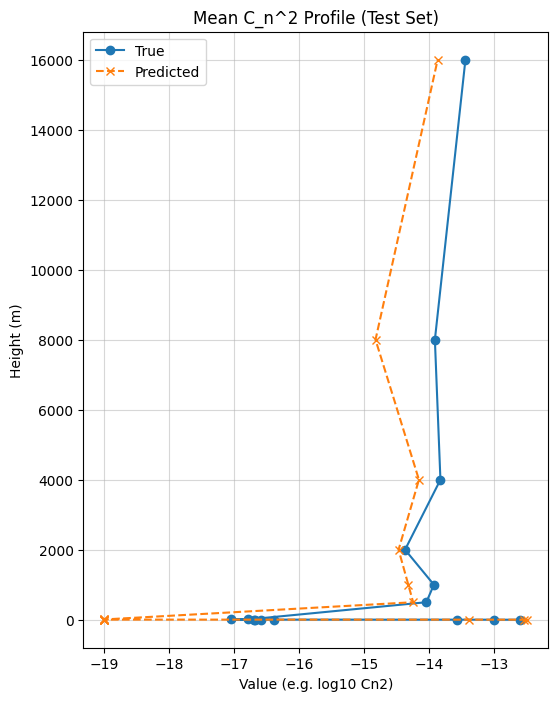

In [6]:
plt.figure(figsize=(10, 8))
plot_profile_comparison(y_test, y_pred, feature_names=task.get_target_name(), title="Mean C_n^2 Profile (Test Set)")
plt.show()

<Figure size 1200x600 with 0 Axes>

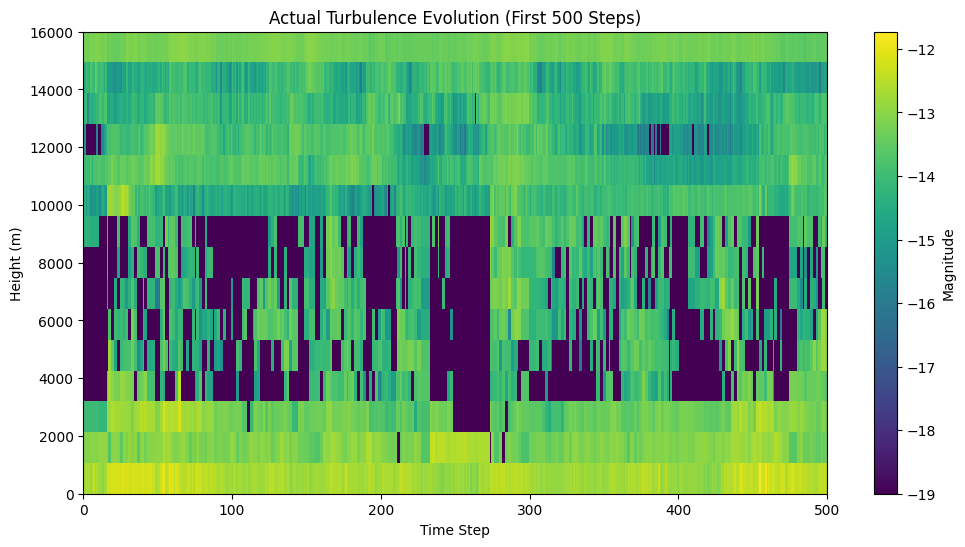

In [7]:
plt.figure(figsize=(12, 6))
plot_time_series_heatmap(y_test.iloc[:500], feature_names=task.get_target_name(), title="Actual Turbulence Evolution (First 500 Steps)")
plt.show()

<Figure size 1200x600 with 0 Axes>

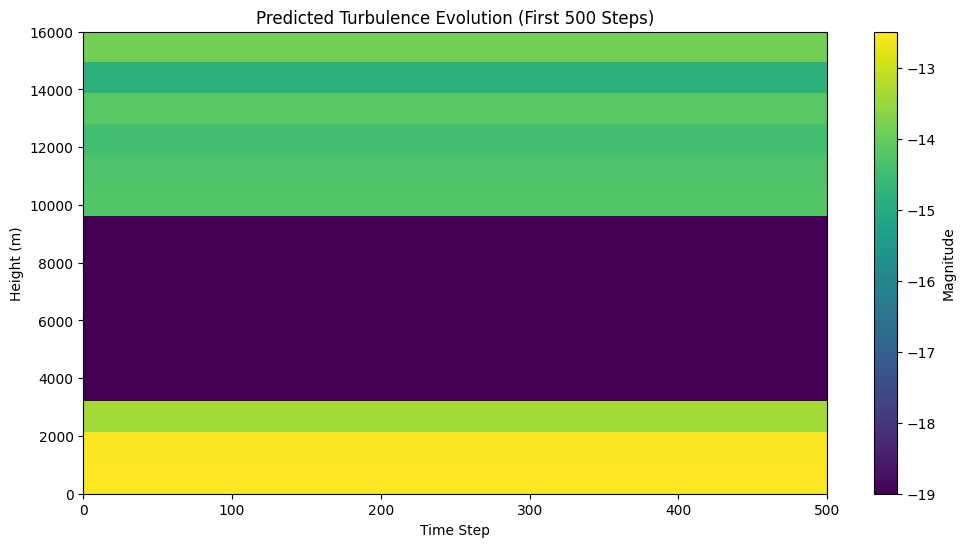

In [8]:
plt.figure(figsize=(12, 6))
plot_time_series_heatmap(y_pred[:500], feature_names=task.get_target_name(), title="Predicted Turbulence Evolution (First 500 Steps)")
plt.show()